In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss, brier_score_loss


from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss,
    brier_score_loss, confusion_matrix, precision_score, recall_score,
)
from fairlearn.metrics import (
    MetricFrame, selection_rate, count, true_positive_rate,
    false_positive_rate, demographic_parity_difference,
    demographic_parity_ratio, equalized_odds_difference,
    equalized_odds_ratio,
)

def confusion_matrix_binary(y_true, y_pred):
    return confusion_matrix(y_true, y_pred, labels=[0, 1])

def false_positive_rate_metric(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return fp/(tn+fp) if (tn+fp)>0 else np.nan

def true_negative_rate_metric(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return tn/(tn+fp) if (tn+fp)>0 else np.nan

def negative_predictive_value_metric(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return tn/(tn+fn) if (tn+fn)>0 else np.nan

# Week 3: Evaluation using reference ground-truth, mitigation, and calibration

You now receive:

- `week3_validation_reference.csv`
- `week3_test_observed.csv`
- `week3_test_reference.csv`

These files let you compare evaluation against the labels available to the modelling pipeline, $Y^{obs}$, and the best available reference labels, $Y^{ref}$.

You now receive the "clean" reference labels (`income_reference`) for the validation and test sets. 

Your objective this week is to uncover the **root cause** of the biases and anomalies you hypothesized in Week 2. By comparing your model's performance against the observed labels ($Y^{obs}$) versus the clean reference labels ($Y^{ref}$), you will finally validate (or invalidate!) your previous hypotheses.

Once you have identified the true source of the bias, you will design and implement a mitigation strategy of your choice to correct it. 

**Rules**
- Do not train a predictive model on `income_reference`.                                    
- Reference validation may be used for final model selection or calibration only if you explicitly state and defend that design choice.                         
- Reference test is used exactly *once* for your final evaluation.                                         
- Preserve `row_id` when joining files and verify one-to-one joins.

In [1]:
%pip -q install fairlearn cleanlab scikit-learn pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
DATA_DIR = Path("./data/data")

train = pd.read_csv(DATA_DIR / "week2_train_observed.csv")
val_obs = pd.read_csv(DATA_DIR / "week2_validation_observed.csv")
val_ref = pd.read_csv(DATA_DIR / "week3_validation_reference.csv")
test_obs = pd.read_csv(DATA_DIR / "week3_test_observed.csv")
test_ref = pd.read_csv(DATA_DIR / "week3_test_reference.csv")

# TODO: assert unique row_id values and exact alignment of feature columns.
print(train.shape, val_obs.shape, val_ref.shape, test_obs.shape, test_ref.shape)

(18000, 15) (6000, 15) (6000, 16) (6000, 15) (6000, 16)


To start with - Compare $Y^{obs}$ and $Y^{ref}$ on validation and test data. Report overall disagreement, disagreement conditional on each label, group-specific disagreement, and intersections. Inspect which feature regions contain disagreements without assuming the reference label is infallible.

In [7]:
# TODO: join observed and reference files by row_id.
# TODO: quantify and visualize label disagreement.

# Overall disagreement
print(f"Number of inconsistent labels in validation set: {sum(val_ref['income_observed']!=val_ref['income_reference'])}")
print(f"Number of inconsistent labels in test set: {sum(test_ref['income_observed']!=test_ref['income_reference'])}")
print()
print(f"Number of rows with y_obs=1 in validation set: {sum(val_ref['income_observed']==1)}")
print(f"Number of rows with y_ref=1 in validation set: {sum(val_ref['income_reference']==1)}")
print()
print(f"Number of rows with y_obs=1 in test set: {sum(test_ref['income_observed']==1)}")
print(f"Number of rows with y_ref=1 in test set: {sum(test_ref['income_reference']==1)}")
print()
# Disagreement conditional on each label
print(f"Validation: Given y_obs = 1, how many y_ref = 1: {sum((val_ref['income_observed'] == 1) & (val_ref['income_reference'] == 1))}")
print(f"Validation: Given y_obs = 0, how many y_ref = 1: {sum((val_ref['income_observed'] == 0) & (val_ref['income_reference'] == 1))}")
print()
print(f"Test: Given y_obs = 1, how many y_ref = 1: {sum((test_ref['income_observed'] == 1) & (test_ref['income_reference'] == 1))}")
print(f"Test: Given y_obs = 0, how many y_ref = 1: {sum((test_ref['income_observed'] == 0) & (test_ref['income_reference'] == 1))}")

# print()
# print("Distribution of binary labels for validation")
# print(val_ref['income_observed'].value_counts())
# print(val_ref['income_reference'].value_counts())

# print()
# print("Distribution of binary labels for test")
# print(test_ref['income_observed'].value_counts())
# print(test_ref['income_reference'].value_counts())



Number of inconsistent labels in validation set: 242
Number of inconsistent labels in test set: 249

Number of rows with y_obs=1 in validation set: 2006
Number of rows with y_ref=1 in validation set: 2188

Number of rows with y_obs=1 in test set: 1992
Number of rows with y_ref=1 in test set: 2189

Validation: Given y_obs = 1, how many y_ref = 1: 1976
Validation: Given y_obs = 0, how many y_ref = 1: 212

Test: Given y_obs = 1, how many y_ref = 1: 1966
Test: Given y_obs = 0, how many y_ref = 1: 223


In [20]:
def compare_distribution_income(column, dataset):

    # Split by observed/reference income
    obs0 = dataset[dataset["income_observed"] == 0]
    obs1 = dataset[dataset["income_observed"] == 1]
    ref0 = dataset[dataset["income_reference"] == 0]
    ref1 = dataset[dataset["income_reference"] == 1]

    # Count values
    if column in ["OCCP", "POBP", "WKHP"]:
        obs0 = obs0[column].value_counts().nlargest(20)
        obs1 = obs1[column].value_counts().nlargest(20)
        ref0 = ref0[column].value_counts().nlargest(20)
        ref1 = ref1[column].value_counts().nlargest(20)
    else:
        obs0 = obs0[column].value_counts()
        obs1 = obs1[column].value_counts()
        ref0 = ref0[column].value_counts()
        ref1 = ref1[column].value_counts()

    # Combine everything so categories are aligned
    comparison = pd.concat(
        [obs0, ref0, obs1, ref1],
        axis=1,
        keys=["obs_0", "ref_0", "obs_1", "ref_1"]
    ).fillna(0)

    # Calculate differences
    comparison["diff_0"] = comparison["obs_0"] - comparison["ref_0"]
    comparison["diff_1"] = comparison["obs_1"] - comparison["ref_1"]

    # Keep only the useful columns
    comparison = comparison[["obs_0", "ref_0", "diff_0",
                             "obs_1", "ref_1", "diff_1"]]

    return comparison

In [22]:
# Group specific disagreement
for col in ['AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP', 'WKHP', 'SEX', 'RAC1P']:
    print(compare_distribution_income(col, val_ref))

      obs_0  ref_0  diff_0  obs_1  ref_1  diff_1
AGEP                                            
30.0  117.0  107.0    10.0   33.0   43.0   -10.0
21.0  109.0  109.0     0.0    1.0    1.0     0.0
22.0  101.0  101.0     0.0    3.0    3.0     0.0
32.0  100.0   92.0     8.0   38.0   46.0    -8.0
25.0   99.0   98.0     1.0   25.0   26.0    -1.0
...     ...    ...     ...    ...    ...     ...
79.0    3.0    2.0     1.0    5.0    6.0    -1.0
82.0    3.0    3.0     0.0    4.0    4.0     0.0
84.0    2.0    2.0     0.0    0.0    0.0     0.0
86.0    0.0    0.0     0.0    1.0    1.0     0.0
85.0    0.0    0.0     0.0    1.0    1.0     0.0

[71 rows x 6 columns]
     obs_0  ref_0  diff_0  obs_1  ref_1  diff_1
COW                                            
1.0   2795   2682     113   1338   1451    -113
6.0    326    318       8    123    131      -8
2.0    276    259      17    122    139     -17
3.0    241    214      27    126    153     -27
4.0    173    162      11    123    134     -11
7.0 

In [38]:
val_ref["label_changed"] = (
    val_ref["income_observed"] != val_ref["income_reference"]
)
print(val_ref.groupby("SEX_group")["label_changed"].mean())
print(val_ref.groupby("RACE_group")["label_changed"].mean())

SEX_group
Female    0.072546
Male      0.011920
Name: label_changed, dtype: float64
RACE_group
AIAN specified/other    0.000000
American Indian         0.050000
Asian                   0.094340
Black                   0.022814
Other race              0.010676
Pacific Islander        0.000000
Two or more races       0.044776
White                   0.040400
Name: label_changed, dtype: float64


We see that labels changed more often for females than males. However, labels changed for Asians, but not as mush for either White or Black

In [40]:
val_ref["label_transition"] = (
    val_ref["income_observed"].astype(str)
    + " -> "
    + val_ref["income_reference"].astype(str)
)

print(pd.crosstab(
    val_ref["SEX_group"],
    val_ref["label_transition"],
    normalize="index"
))

print(pd.crosstab(
    val_ref["RACE_group"],
    val_ref["label_transition"],
    normalize="index"
))

label_transition    0 -> 0    0 -> 1    1 -> 0    1 -> 1
SEX_group                                               
Female            0.711593  0.066501  0.006046  0.215861
Male              0.558657  0.007842  0.004078  0.429423
label_transition        0 -> 0    0 -> 1    1 -> 0    1 -> 1
RACE_group                                                  
AIAN specified/other  0.866667  0.000000  0.000000  0.133333
American Indian       0.750000  0.050000  0.000000  0.200000
Asian                 0.547170  0.084906  0.009434  0.358491
Black                 0.741445  0.022814  0.000000  0.235741
Other race            0.839858  0.010676  0.000000  0.149466
Pacific Islander      0.666667  0.000000  0.000000  0.333333
Two or more races     0.679104  0.029851  0.014925  0.276119
White                 0.608335  0.035084  0.005316  0.351265


The above shows that about 7% of women labels switched from 0 to 1. However, the labels for men didnt really change.

8% of Asian labels changed from 0 to 1, whereas it was only 2-3% for White and Black. There wasn't really a change fromm 1 to 0 for any race

This indicates that there might have been group-dependent label corruption for women and Asians, which supports one of the hypotheses. In both cases, these groups have been projected to earn less than they do

In [25]:
# TODO: test the Week 2 hypotheses without reading the new metadata.

## Re-evaluate the original model twice

For the same scores and decisions, produce two complete audits:

1. against `income_observed`;
2. against `income_reference`.

Any difference is caused by the evaluation target, not by a changed model. Discuss which conclusions reverse or materially change.

In [28]:
# TODO: reconstruct your Week 2 baseline.
LABEL = "income_observed"
ID = "row_id"
SENSITIVE = ["SEX_group", "RACE_group"]

FEATURE_COLUMNS = ["AGEP", "COW", "SCHL", "MAR", "OCCP", "POBP", "RELP", "WKHP", "SEX", "RAC1P"]
NUMERIC = ["AGEP", "WKHP"]

def make_model(frame, C=1.0):
    numeric = [c for c in NUMERIC if c in frame.columns]
    categorical = [c for c in FEATURE_COLUMNS if c not in numeric]
    prep = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ])
    return Pipeline([
        ("preprocess", prep),
        ("model", LogisticRegression(max_iter=1000, C=C)),
    ])


# Logistic regression model
model = make_model(train[FEATURE_COLUMNS])
model.fit(train[FEATURE_COLUMNS], train["income_observed"])

# Measure performance with income_observed vs income_reference
val_score = model.predict_proba(val_ref[FEATURE_COLUMNS])[:, 1]
val_pred = (val_score >= .5).astype(int)

logistic_accuracy_obs = accuracy_score(val_ref["income_observed"], val_pred)
logistic_accuracy_ref = accuracy_score(val_ref["income_reference"], val_pred)

# Baseline model
baseline_pred = (val_ref['WKHP']> 40).astype(int)
baseline_accuracy_obs = accuracy_score(val_ref["income_observed"], baseline_pred)
baseline_accuracy_ref = accuracy_score(val_ref["income_reference"], baseline_pred)

print(f"Logistic regression accuracy with income_observed: {logistic_accuracy_obs:.3f}")
print(f"WKHP baseline accuracy with income_observed: {baseline_accuracy_obs:.3f}")
print()
print(f"Logistic regression accuracy with income_reference: {logistic_accuracy_ref:.3f}")
print(f"WKHP baseline accuracy with income_reference: {baseline_accuracy_ref:.3f}")

Logistic regression accuracy with income_observed: 0.798
WKHP baseline accuracy with income_observed: 0.703

Logistic regression accuracy with income_reference: 0.800
WKHP baseline accuracy with income_reference: 0.694


In [35]:
# TODO: create a reusable audit function accepting y_eval, scores, predictions, and sensitive features.
# TODO: report utility, independence, separation, sufficiency, and calibration twice.

def audit(dataset, y_eval, scores, predictions, sensitive_features=None, calibration=False):

    metrics = {
    "n": count,
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "selection_rate": selection_rate,
    "TPR_recall": recall_score,
    "FPR": false_positive_rate_metric,
    "PPV_precision": lambda y, p: precision_score(y, p, zero_division=0),
    "NPV": negative_predictive_value_metric,
    "TNR": true_negative_rate_metric,
    "confusion_matrix": confusion_matrix_binary,
    "ROC_AUC": roc_auc_score,
    "log_loss": log_loss
    }


    if sensitive_features:
        mf = MetricFrame(metrics=metrics, y_true=y_eval, y_pred=predictions, sensitive_features=dataset[sensitive_features[0]])
        print("Overall threshold metrics")
        display(pd.Series(mf.overall))
        print("By group")
        display(mf.by_group)
        fairness_summary = pd.Series({
                    "demographic_parity_difference": demographic_parity_difference(y_eval, predictions, sensitive_features=dataset[sensitive_features[0]]), 
                    "demographic_parity_ratio": demographic_parity_ratio(y_eval, predictions, sensitive_features=dataset[sensitive_features[0]]),
                    "equalized_odds_difference": equalized_odds_difference(y_eval, predictions, sensitive_features=dataset[sensitive_features[0]]),
                    "equalized_odds_ratio": equalized_odds_ratio(y_eval, predictions, sensitive_features=dataset[sensitive_features[0]]),
                })
        display(fairness_summary)
        
    else:
        mf = MetricFrame(metrics=metrics, y_true=y_eval, y_pred=predictions)
        print("Overall threshold metrics")
        display(pd.Series(mf.overall))

    if len(sensitive_features)>1:
        for i in range(1,len(sensitive_features)):
            mf = MetricFrame(metrics=metrics, y_true=y_eval, y_pred=predictions, sensitive_features=dataset[sensitive_features[i]])
            display(mf.by_group)

            fairness_summary = pd.Series({
                "demographic_parity_difference": demographic_parity_difference(y_eval, predictions, sensitive_features=dataset[sensitive_features[i]]), 
                "demographic_parity_ratio": demographic_parity_ratio(y_eval, predictions, sensitive_features=dataset[sensitive_features[i]]),
                "equalized_odds_difference": equalized_odds_difference(y_eval, predictions, sensitive_features=dataset[sensitive_features[i]]),
                "equalized_odds_ratio": equalized_odds_ratio(y_eval, predictions, sensitive_features=dataset[sensitive_features[i]]),
            })
            display(fairness_summary)

    # Calibration
    if calibration:
        for j, sen in enumerate(sensitive_features):
            calibration_data = pd.DataFrame({
                "y_true": y_eval.to_numpy(),
                "y_prob": scores,
                "group": dataset[sen].to_numpy()
            })

            n_bins = 10

            plt.figure(figsize=(8, 7))

            for group, group_df in calibration_data.groupby("group"):
                group_df = group_df.copy()

                group_df["bin"] = pd.cut(
                    group_df["y_prob"],
                    bins=np.linspace(0, 1, n_bins + 1),
                    include_lowest=True
                )

                calibration_group = (
                    group_df
                    .groupby("bin", observed=False)
                    .agg(
                        n=("y_true", "size"),
                        mean_predicted=("y_prob", "mean"),
                        observed_rate=("y_true", "mean")
                    )
                )

                # Only plot bins containing observations
                calibration_group = calibration_group[calibration_group["n"] > 0]

                plt.plot(
                    calibration_group["mean_predicted"],
                    calibration_group["observed_rate"],
                    marker="o",
                    label=str(group)
                )

            # Perfect calibration
            plt.plot(
                [0, 1],
                [0, 1],
                linestyle="--",
                label="Perfect calibration"
            )

            plt.xlabel("Mean predicted probability")
            plt.ylabel("Observed positive rate")
            plt.title("Reliability plot by sensitive group")
            plt.legend(title=SENSITIVE if isinstance(SENSITIVE, str) else "Group")
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()

Overall threshold metrics


n                                          6000
accuracy                                  0.798
balanced_accuracy                      0.757829
selection_rate                         0.293333
TPR_recall                              0.63659
FPR                                    0.120931
PPV_precision                          0.725568
NPV                                    0.828066
TNR                                    0.879069
confusion_matrix     [[3511, 483], [729, 1277]]
ROC_AUC                                0.757829
log_loss                               7.280818
dtype: object

By group


,n,accuracy,balanced_accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV,TNR,confusion_matrix,ROC_AUC,log_loss
SEX_group,,,,,,,,,,,,
Female,2812,0.806543,0.659754,0.147226,0.395833,0.076325,0.596618,0.842786,0.923675,"[[2021, 167], [377, 247]]",0.659754,6.972883
Male,3188,0.790464,0.785162,0.422208,0.745297,0.174972,0.765230,0.808903,0.825028,"[[1490, 316], [352, 1030]]",0.785162,7.552434


demographic_parity_difference    0.274982
demographic_parity_ratio         0.348705
equalized_odds_difference        0.349463
equalized_odds_ratio             0.436214
dtype: float64

,n,accuracy,balanced_accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV,TNR,confusion_matrix,ROC_AUC,log_loss
RACE_group,,,,,,,,,,,,
AIAN specified/other,15,0.933333,0.750000,0.066667,0.500000,0.000000,1.000000,0.928571,1.000000,"[[13, 0], [1, 1]]",0.750000,2.402910e+00
American Indian,20,0.900000,0.843750,0.200000,0.750000,0.062500,0.750000,0.937500,0.937500,"[[15, 1], [1, 3]]",0.843750,3.604365e+00
Asian,318,0.795597,0.790088,0.402516,0.769231,0.189055,0.703125,0.857895,0.810945,"[[163, 38], [27, 90]]",0.790088,7.367413e+00
Black,526,0.790875,0.631740,0.129278,0.330645,0.067164,0.602941,0.818777,0.932836,"[[375, 27], [83, 41]]",0.631740,7.537646e+00
Other race,281,0.871886,0.679368,0.099644,0.404762,0.046025,0.607143,0.901186,0.953975,"[[228, 11], [25, 17]]",0.679368,4.617692e+00
Pacific Islander,3,1.000000,1.000000,0.333333,1.000000,0.000000,1.000000,1.000000,1.000000,"[[2, 0], [0, 1]]",1.000000,2.220446e-16
Two or more races,134,0.791045,0.701484,0.201493,0.487179,0.084211,0.703704,0.813084,0.915789,"[[87, 8], [20, 19]]",0.701484,7.531510e+00
White,4703,0.793749,0.763694,0.319583,0.658915,0.131527,0.735196,0.821250,0.868473,"[[2628, 398], [572, 1105]]",0.763694,7.434051e+00


demographic_parity_difference    0.335849
demographic_parity_ratio         0.165625
equalized_odds_difference        0.669355
equalized_odds_ratio             0.000000
dtype: float64

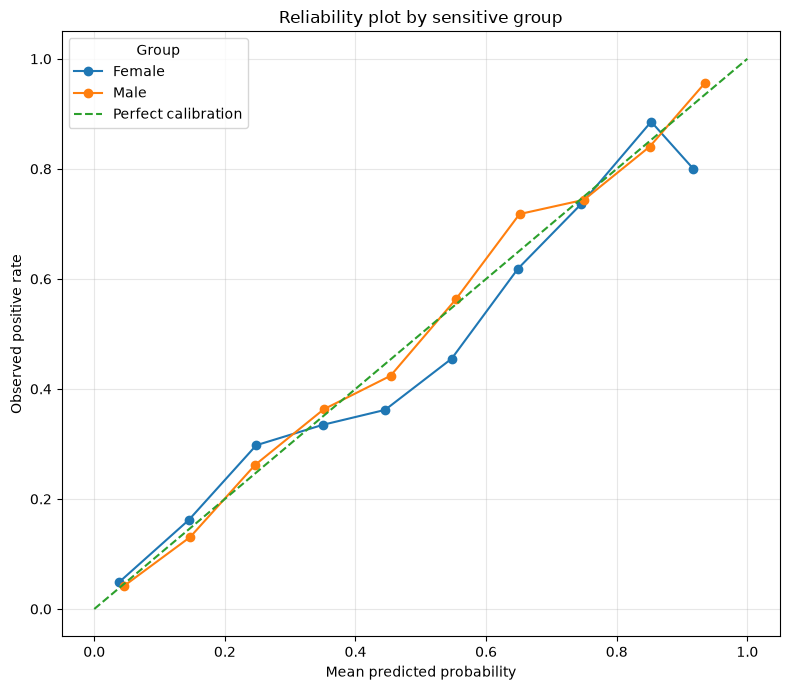

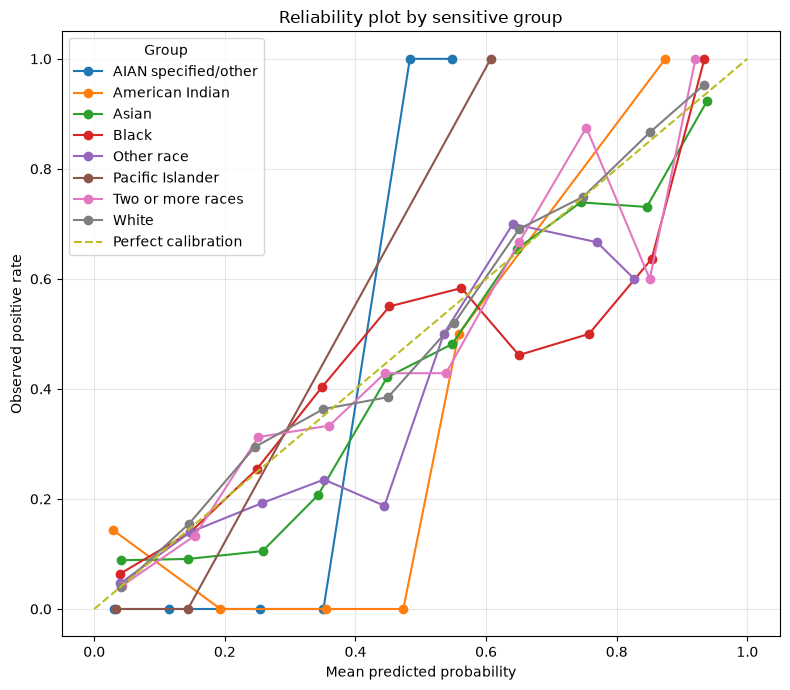

In [36]:
audit(val_ref, val_ref["income_observed"], val_score, val_pred, sensitive_features=SENSITIVE, calibration=True)

Overall threshold metrics


n                                          6000
accuracy                               0.799667
balanced_accuracy                      0.762996
selection_rate                         0.293333
TPR_recall                             0.627514
FPR                                    0.101522
PPV_precision                          0.780114
NPV                                    0.807783
TNR                                    0.898478
confusion_matrix     [[3425, 387], [815, 1373]]
ROC_AUC                                0.762996
log_loss                               7.220745
dtype: object

By group


,n,accuracy,balanced_accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV,TNR,confusion_matrix,ROC_AUC,log_loss
SEX_group,,,,,,,,,,,,
Female,2812,0.804410,0.686118,0.147226,0.414358,0.042121,0.794686,0.806088,0.957879,"[[1933, 85], [465, 329]]",0.686118,7.049790
Male,3188,0.795483,0.790293,0.422208,0.748924,0.168339,0.775632,0.809989,0.831661,"[[1492, 302], [350, 1044]]",0.790293,7.371538


demographic_parity_difference    0.274982
demographic_parity_ratio         0.348705
equalized_odds_difference        0.334566
equalized_odds_ratio             0.250215
dtype: float64

,n,accuracy,balanced_accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV,TNR,confusion_matrix,ROC_AUC,log_loss
RACE_group,,,,,,,,,,,,
AIAN specified/other,15,0.933333,0.750000,0.066667,0.500000,0.000000,1.000000,0.928571,1.000000,"[[13, 0], [1, 1]]",0.750000,2.402910e+00
American Indian,20,0.850000,0.766667,0.200000,0.600000,0.066667,0.750000,0.875000,0.933333,"[[14, 1], [2, 3]]",0.766667,5.406548e+00
Asian,318,0.808176,0.800998,0.402516,0.737589,0.135593,0.812500,0.805263,0.864407,"[[153, 24], [37, 104]]",0.800998,6.914034e+00
Black,526,0.779468,0.630995,0.129278,0.323529,0.061538,0.647059,0.799127,0.938462,"[[366, 24], [92, 44]]",0.630995,7.948790e+00
Other race,281,0.868327,0.678814,0.099644,0.400000,0.042373,0.642857,0.893281,0.957627,"[[226, 10], [27, 18]]",0.678814,4.745961e+00
Pacific Islander,3,1.000000,1.000000,0.333333,1.000000,0.000000,1.000000,1.000000,1.000000,"[[2, 0], [0, 1]]",1.000000,2.220446e-16
Two or more races,134,0.791045,0.706268,0.201493,0.487805,0.075269,0.740741,0.803738,0.924731,"[[86, 7], [21, 20]]",0.706268,7.531510e+00
White,4703,0.796725,0.769648,0.319583,0.650523,0.111227,0.786427,0.801562,0.888773,"[[2565, 321], [635, 1182]]",0.769648,7.326756e+00


demographic_parity_difference    0.335849
demographic_parity_ratio         0.165625
equalized_odds_difference        0.676471
equalized_odds_ratio             0.000000
dtype: float64

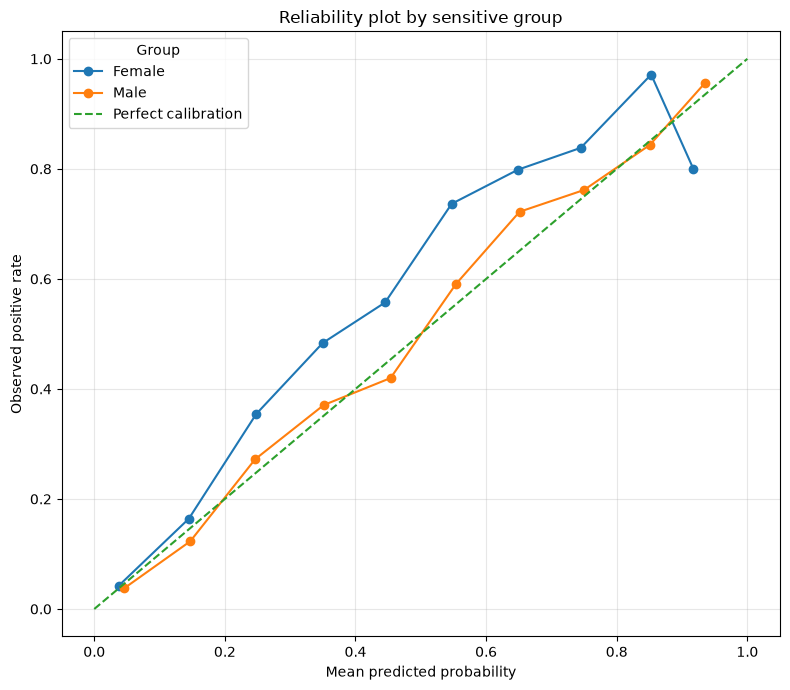

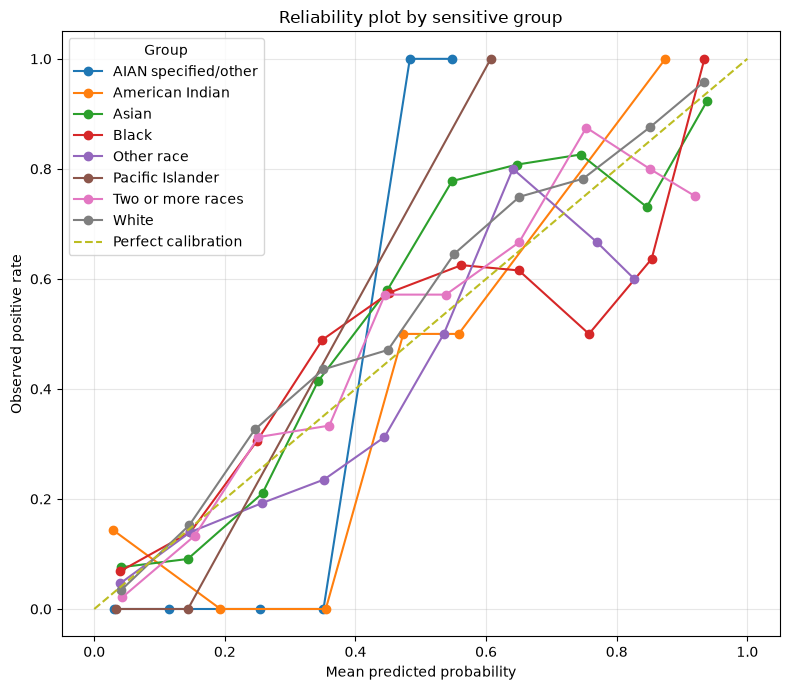

In [37]:
audit(val_ref, val_ref["income_reference"], val_score, val_pred, sensitive_features=SENSITIVE, calibration=True)

Y_observed (biased labels) vs Y_ref (unbiased labels)
selection rate did not change
TPR and FPR increased a little for females (about 0.03)
Precision increased a lot for women (from 0.60 to 0.79), while only 0.01 for men
NPV increased for women (0.04)
TNR increased a little for both 
ROC_AUC increased for both though most for women (0.02)
Demographic parity did not change
Equalized odds ratio went down significantly (from 0.43 to 0.25)
Women were underestimated before, now they are over-estimated (calibration plot)

Since precision changed substantially using the reference labels, and we have seen how the observed labels were biased towards women with high income, we can say that some of the gender performance under y_obs was an artifact of the labels.


Accuracy went down a little for Black
Selection rate did not change for white/black
Precision went up a bit for white and black
White are not a bit overestimated (calibration plot). The model seems to be as badly calibrated for blacks as before
Asians were a bit underestimated before, now they are a bit overestimated.

Similar to above, precision also increased when using the reference labels, and we saw the same trend in biased labels, so we may make the same conclusion. However, the hypotheses focused on White vs Black. According to chat: The reference labels materially change some race-specific performance and calibration results, but the evidence for a single race-related mechanism is less clear than for gender. In particular, persistent calibration problems for Black individuals after replacing \(Y^{obs}\) with \(Y^{ref}\) suggest that the issue may not be explained solely by label corruption.

In [ ]:
def create_flip_experiments(y_train, flip_percentages=(10, 20, 30, 40, 50, 60, 70, 80, 90, 100),  random_state=42):
    """
    Create progressively corrupted versions of y_train.

    Returns
    -------
    experiments : dict
        experiments[p] contains:
            - y_flipped: corrupted labels
            - flipped_indices: original indices that were flipped
            - flip_mask: boolean Series indexed like y_train
    """

    rng = np.random.default_rng(random_state)

    # Preserve the original index
    indices = np.asarray(y_train.index)

    # One fixed random ordering.
    # This makes the experiments nested:
    # 20% contains all flips from 10%, etc.
    shuffled_indices = rng.permutation(indices)

    experiments = {}

    n = len(y_train)

    for percentage in flip_percentages:

        n_flip = int(round(n * percentage / 100))

        flipped_indices = shuffled_indices[:n_flip]

        # Start from clean labels
        y_flipped = y_train.copy()

        # Flip binary labels: 0 -> 1, 1 -> 0
        y_flipped.loc[flipped_indices] = 1 - y_flipped.loc[flipped_indices]

        # Keep an explicit record of what was flipped
        flip_mask = pd.Series(False, index=y_train.index)
        flip_mask.loc[flipped_indices] = True

        experiments[percentage] = {
            "y_flipped": y_flipped,
            "flipped_indices": flipped_indices,
            "flip_mask": flip_mask
        }

    return experiments

## Design mitigation candidates

Compare at least four methods you could think of. You may add models. Every intervention requires a  rationale and a documented cost/tradeoff.

Hint: `ThresholdOptimizer` changes decisions, not probability calibration. `ExponentiatedGradient` trains a randomized classifier under a constraint. Equalized odds is evaluated relative to the label supplied during fitting.

Compare at least these score pipelines:

1. uncalibrated model;
2. calibration fitted to observed validation labels;
3. calibration fitted to reference validation labels.

Evaluate each against both observed and reference test labels. Keep calibration separate from decision postprocessing. Explain why a score can be calibrated against one label and miscalibrated against another.

In [ ]:
# TODO: define the candidates and a common experiment protocol.
# Keep preprocessing, split, random seed, and evaluation consistent.

Candidate 1: Baseline - The unmitigated logistic regression model trained on the observed labels <- Works as a control

Candidate 2: Calibration using y_obs <- Same as last time. Works as another control

Candidate 3: Calibration using y_ref <- See if we get better results if we know the real labels. However, in the real world these will often not be available

Candidate 4: ExponentiatedGradient <- Train with fairness in mind


In [41]:
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import EqualizedOdds, ExponentiatedGradient
from sklearn.linear_model import LogisticRegression

# TODO: choose which validation label is appropriate for fitting a postprocessor.
# post = ThresholdOptimizer(estimator=base_model, constraints="equalized_odds", predict_method="predict_proba")
# post.fit(X_val, y_val_..., sensitive_features=A_val)

# TODO: implement, justify, and audit Fairlearn interventions.

In [49]:
# Candidate 2
postprocessor_sex_obs = ThresholdOptimizer(estimator=model, constraints="equalized_odds", objective="accuracy_score", predict_method="predict_proba", prefit=True)
postprocessor_sex_obs.fit(val_ref[FEATURE_COLUMNS], val_ref["income_observed"], sensitive_features=val_ref["SEX_group"])
post_eqodd_obs_pred = postprocessor_sex_obs.predict(val_ref[FEATURE_COLUMNS], sensitive_features=val_ref["SEX_group"])

# Candidate 3
postprocessor_sex_ref = ThresholdOptimizer(estimator=model, constraints="equalized_odds", objective="accuracy_score", predict_method="predict_proba", prefit=True)
postprocessor_sex_ref.fit(val_ref[FEATURE_COLUMNS], val_ref["income_reference"], sensitive_features=val_ref["SEX_group"])
post_eqodd_ref_pred = postprocessor_sex_ref.predict(val_ref[FEATURE_COLUMNS], sensitive_features=val_ref["SEX_group"])

In [50]:
# Candidate 4
base_model = LogisticRegression(max_iter=2000)
ex_grad = ExponentiatedGradient(estimator=base_model, constraints=EqualizedOdds(),max_iter=200)
ex_grad.fit(train[FEATURE_COLUMNS], train['income_observed'], sensitive_features=train['SEX'])
ex_grad_predictions = ex_grad.predict(val_ref[FEATURE_COLUMNS])

c:\Users\bella\miniconda3\envs\RAI\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\bella\miniconda3\envs\RAI\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproces

In [ ]:
audit(val_ref, val_ref["income_reference"], ..., post_eqodd_obs_pred, sensitive_features=["SEX_group"], calibration=False) # Candidate 2
audit(val_ref, val_ref["income_reference"], ..., post_eqodd_ref_pred, sensitive_features=["SEX_group"], calibration=False) # Candidate 3
audit(val_ref, val_ref["income_reference"], ..., ex_grad_predictions, sensitive_features=["SEX_group"], calibration=False) # Candidate 4



In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# Current sklearn pattern for a pre-fitted estimator. The calibration set
# must be disjoint from the model-fitting set:
# calibrated_obs = CalibratedClassifierCV(
#     estimator=FrozenEstimator(base_model), method="sigmoid"
# )
# calibrated_obs.fit(X_val, y_val_observed)

# TODO: implement all three pipelines, reliability plots, ECE, and log loss.

## 5. Final locked test evaluation

Select the final candidates before examining reference test results. Then produce evaluate a comparison with:

- performance against $Y^{obs}$ and $Y^{ref}$;
- sex-specific and intersectional counts;
- selection-rate gap;
- TPR and FPR gaps;
- PPV and NPV gaps;
- AUROC, log loss, and calibration error;
- bootstrap intervals for key gaps;
- number of training examples removed/reweighted;
- features required at deployment.
- etc

## Questions to think about!

1. Which Week 2 conclusions were robust to the reference label audit?
2. Which apparent performance or fairness results were artifacts of $Y^{obs}$?
3. How did the suspected issue X affect in-distribution validation and shifted test performance?
4. How methods/framework helped you find issues in the data? How do you know?
5. Which mitigation improved reference performance, and what did it cost?
6. Did a parity intervention improve the chosen harm-related metric against the correct label?
7. How did observed-label and reference-label calibration differ?
8. Why can equalized odds and calibration conflict when group base rates differ?
9. What evidence would be required before changing real labels or deploying group-specific thresholds?
10. What remains unvalidated?

# 📌 Final Submission for Project 1: A0 Poster

You are instructed to submit an A0 poster summarizing  findings across the three weeks.

## 📋 Recommended Poster Structure

### Introduction & Setup (very breifly)

* The prediction task, dataset, and outcome. 
* The critical distinction between $Y^{obs}$ (the potential corrupted label) and $Y^{ref}$ (the clean ground-truth label).

### Week 1: Baseline Fairness Audit

* Overall and group-specific predictive performance.
* Fairness metrics considered and the real-world trade-offs observed.

### Week 2: Blind Audit (Observed Labels)

* You must explain initial hypotheses (e.g., Data collection flaws? Group-dependent errors? Spurious correlations?).
* What audit methods they used, their strongest evidence, and whether they trust derived scores as ground truth.

### Week 3: Reference Label Evaluation and Mitigation

* Reveal the hidden data problem using $Y^{ref}$ and quantify the disagreement between the observed and reference labels.
* Discuss whether your Week 2 hypotheses were correct.
* Mitigation: Compare a justified set of interventions. Report the effect on performance, fairness, calibration, and any adverse effects.
* Final Selection: Present the final model selection and its evaluation on the reference test set.
* Discussion and Conclusion

### Important

* Use visual evidence (tables/figures) throughout the poster. Focus on interpretation over code.

* Report relevant negative or inconclusive findings. What remains unvalidated?